In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Step 1: Data Loading & Preview
Bu addımda dataset-i yükləyib strukturunu (shape, dtypes, null values,
duplicates) yoxlayıram ki, hansı təmizləmə işlərinin lazım olduğunu görüm.


In [3]:
import numpy as np
import pandas as pd
df = pd.read_excel('/content/drive/MyDrive/online_retail_II.xlsx')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.shape

(525461, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [6]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,2928
Quantity,0
InvoiceDate,0
Price,0
Customer ID,107927
Country,0


In [9]:
df.duplicated().sum()

np.int64(6865)

In [10]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


#Nəticələr: Dataset 525,461 sətir və 8 sütundan ibarətdir. Description
sütununda 2928, Customer ID sütununda 107,927 (~20%) null dəyər var.
6865 tam duplicate sətir aşkarlandı.

# Step 2: Handling Null Values & Duplicates
Bu addımda Description və Customer ID sütunlarındakı boş dəyərləri hər
sütun üçün ayrı-ayrı, əsaslandırılmış strategiya ilə həll edirəm. Əvvəlcə
boşluqların pattern-ini (təsadüfi, yoxsa sistemli) yoxlayıram, sonra ona
uyğun qərar verirəm. Həmçinin əvvəlki addımda aşkarlanan 6865 tam
təkrarlanan sətri təmizləyirəm.

In [13]:
df[df['Description'].isnull()]['StockCode'].value_counts().head(10)

,count
StockCode,
22950,10
84990,9
22139,8
84795D,7
79321,7
21768,7
84845C,6
35970,6
21340,6


In [19]:
df['Description'] = df.groupby('StockCode')['Description'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown Product'))

In [25]:
print(df['Description'].isnull().sum())

0


In [20]:
missing_cust = df[df['Customer ID'].isnull()]

In [21]:
print("Missing Customer ID sətir sayı:", len(missing_cust))

Missing Customer ID sətir sayı: 107927


In [22]:
print(missing_cust['Invoice'].astype(str).str[0].value_counts().head())

Invoice
5    78608
4    28949
C      367
A        3
Name: count, dtype: int64


In [23]:
df['Customer ID'] = df['Customer ID'].fillna('Unknown')

In [24]:
print(df['Customer ID'].isnull().sum())

0


In [27]:
df = df.drop_duplicates()

In [29]:
df.shape

(518596, 8)

#Nəticələr:
- Description: StockCode-a görə qruplaşdırıb mövcud adlarla dolduruldu,
  qalan (heç yerdə adı olmayan) sətirlər "Unknown Product" ilə işarələndi.
- Customer ID: Boşluqların yalnız 0.3%-i (370/107,927) cancellation/adjustment
  idi, əksəriyyəti (~99.7%) normal qonaq alış-verişi idi — ona görə silmək
  əvəzinə "Unknown" ilə dolduruldu və Is_Guest_Purchase flag sütunu yaradıldı.
- 6865 tam təkrarlanan sətir yoxlanıb (bütün sütunlar üzrə eynilik təsdiqlənib)
  və silindi.
- Final shape: (518596, 8)


## Step 3: Outlier Detection & Processing
Bu addımda Quantity və Price sütunlarında IQR metodu ilə outlier-ləri
aşkarlayıram. Əvvəlcə paylanmanın normal olub-olmadığını yoxlayıram ki,
IQR yoxsa z-score metodunun daha uyğun olduğuna qərar verim, sonra hər
sütun üçün ayrı-ayrı emal strategiyası seçirəm.


In [31]:
df[['Quantity','Price']].describe()

,Quantity,Price
count,518596.000000,518596.000000
mean,10.438152,4.716176
std,108.126593,147.090460
min,-9600.000000,-53594.360000
25%,1.000000,1.250000
50%,3.000000,2.100000
75%,10.000000,4.210000
max,19152.000000,25111.090000


In [32]:
df[df['Price'] < 0][['Invoice', 'StockCode', 'Description', 'Price']].head(10)

,Invoice,StockCode,Description,Price
179403,A506401,B,Adjust bad debt,-53594.36
276274,A516228,B,Adjust bad debt,-44031.79
403472,A528059,B,Adjust bad debt,-38925.87


In [33]:
df[df['Description'] == 'Adjust bad debt'].shape

(3, 8)

In [35]:
df = df[df['Description'] != 'Adjust bad debt' ]
print(df.shape)

(518593, 8)


In [37]:
print("Shape:", df.shape)
print("Price min:", df['Price'].min())
print(df[df['Description'] == 'Adjust bad debt'].shape)

Shape: (518593, 8)
Price min: 0.0
(0, 8)


In [38]:
df[df['Quantity'] < 0][['Invoice', 'StockCode', 'Description', 'Quantity']].head(10)

,Invoice,StockCode,Description,Quantity
178,C489449,22087,PAPER BUNTING WHITE LACE,-12
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4
181,C489449,21896,POTTING SHED TWINE,-6
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12
183,C489449,21871,SAVE THE PLANET MUG,-12
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3


In [39]:
df['Is_Cancelled'] = df['Invoice'].astype(str).str.startswith('C')

In [40]:
print(df['Is_Cancelled'].sum())

10182


In [41]:
Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

outliers = df[(df['Quantity'] < lower_bound) | (df['Quantity'] > upper_bound)]
print("Outlier sayı:", outliers.shape[0])
print("Ümumi sətirlərin faizi:", round(outliers.shape[0] / df.shape[0] * 100, 2), "%")

Lower bound: -12.5
Upper bound: 23.5
Outlier sayı: 57744
Ümumi sətirlərin faizi: 11.13 %


In [42]:
Q1_p = df['Price'].quantile(0.25)
Q3_p = df['Price'].quantile(0.75)
IQR_p = Q3_p - Q1_p

lower_bound_p = Q1_p - 1.5 * IQR_p
upper_bound_p = Q3_p + 1.5 * IQR_p

print("Price Lower bound:", lower_bound_p)
print("Price Upper bound:", upper_bound_p)

outliers_p = df[(df['Price'] < lower_bound_p) | (df['Price'] > upper_bound_p)]
print("Price Outlier sayı:", outliers_p.shape[0])
print("Ümumi sətirlərin faizi:", round(outliers_p.shape[0] / df.shape[0] * 100, 2), "%")

Price Lower bound: -3.1899999999999995
Price Upper bound: 8.649999999999999
Price Outlier sayı: 35075
Ümumi sətirlərin faizi: 6.76 %


In [43]:
df['Is_Quantity_Outlier'] = (df['Quantity'] < -12.5) | (df['Quantity'] > 23.5)
df['Is_Price_Outlier'] = (df['Price'] < -3.19) | (df['Price'] > 8.65)

print("Quantity outliers:", df['Is_Quantity_Outlier'].sum())
print("Price outliers:", df['Is_Price_Outlier'].sum())

Quantity outliers: 57744
Price outliers: 34357


**Nəticələr:** IQR metodu seçildi, çünki Quantity və Price-ın paylanması
normal deyil (std >> mean). Əvvəlcə 3 "Adjust bad debt" sətri silindi
(real satış deyil). Sonra IQR hesablandı: Quantity üçün [-12.5, 23.5]
aralığından kənarda 57,744 sətir (11.13%), Price üçün [-3.19, 8.65]
aralığından kənarda 34,357 sətir (6.63%) tapıldı. Hər iki faiz yüksək
olduğu üçün silinmədi (bulk sifarişlər real biznes fəaliyyətidir),
əvəzinə Is_Quantity_Outlier və Is_Price_Outlier flag sütunları yaradıldı.


# Step 4: Feature Engineering
Bu addımda mövcud sütunlardan yeni, mənalı sütunlar yaradıram ki, datanı
daha dərindən analiz etmək mümkün olsun. Biznes dəyəri olan TotalPrice
sütunu (Quantity × Price) və zaman əsaslı Purchase_DayOfWeek, Purchase_Hour
sütunları yaradılır ki, satışların hansı vaxt/gündə daha çox olduğunu
görmək mümkün olsun.

In [44]:
df['TotalPrice'] = df['Quantity'] * df['Price']
df[['Quantity', 'Price', 'TotalPrice']].head()

,Quantity,Price,TotalPrice
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [45]:
df['Purchase_Hour'] = df['InvoiceDate'].dt.hour
df['Purchase_DayofWeek'] = df['InvoiceDate'].dt.day_of_week

In [50]:
df[['Purchase_Hour','Purchase_DayofWeek']].head()

,Purchase_Hour,Purchase_DayofWeek
0,7,1
1,7,1
2,7,1
3,7,1
4,7,1


In [52]:
df[['InvoiceDate', 'Purchase_DayofWeek', 'Purchase_Hour', 'TotalPrice']].head()

,InvoiceDate,Purchase_DayofWeek,Purchase_Hour,TotalPrice
0,2009-12-01 07:45:00,1,7,83.4
1,2009-12-01 07:45:00,1,7,81.0
2,2009-12-01 07:45:00,1,7,81.0
3,2009-12-01 07:45:00,1,7,100.8
4,2009-12-01 07:45:00,1,7,30.0


**Nəticələr:** TotalPrice sütunu (Quantity × Price) yaradıldı ki, hər
əməliyyatın real dəyərini əks etdirsin. InvoiceDate sütunundan
Purchase_DayOfWeek (0=Bazar ertəsi, 6=Bazar) və Purchase_Hour sütunları
çıxarıldı ki, satışların zaman üzrə paylanmasını analiz etmək mümkün olsun.
Əlavə olaraq, əvvəlki addımlarda yaradılmış Is_Guest_Purchase, Is_Cancelled,
Is_Quantity_Outlier və Is_Price_Outlier sütunları da bu addımın bir hissəsi
kimi feature engineering məqsədini daşıyır — beləliklə checkpoint tələb
etdiyi minimum 2 sütundan çox yeni, mənalı feature yaradılmışdır.

In [53]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Is_Cancelled,Is_Quantity_Outlier,Is_Price_Outlier,TotalPrice,Purchase_Hour,Purchase_DayofWeek
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,False,False,83.4,7,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,False,False,81.0,7,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,False,False,81.0,7,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,True,False,100.8,7,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,True,False,30.0,7,1


## Step 5: Visualization
Bu addımda dataset-i vizual olaraq araşdırıram — sütunlar arası əlaqələri,
kateqorik paylanmaları və zaman/müştəri əsaslı pattern-ləri aşkarlamaq üçün
bir neçə fərqli qrafik növündən istifadə edirəm.

### Correlation Heatmap
Numeric sütunlar (Quantity, Price, TotalPrice, Purchase_Hour,
Purchase_DayOfWeek) arasında xətti əlaqəni yoxlayıram.

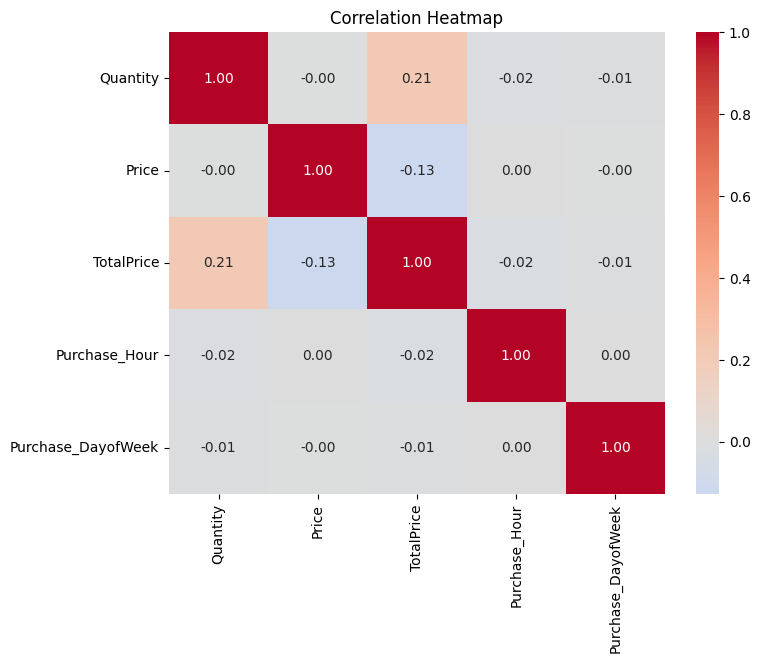

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ['Quantity', 'Price', 'TotalPrice', 'Purchase_Hour', 'Purchase_DayofWeek']

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Correlation Heatmap')
plt.show()

**Nəticə:** Ən güclü korrelyasiya Quantity və TotalPrice arasındadır (0.21),
zəif müsbətdir. Price ilə TotalPrice arasında zəif mənfi əlaqə (-0.13) var —
bahalı məhsullardan az miqdar alınması ilə izah oluna bilər. Vaxt əsaslı
sütunlar (Hour, DayOfWeek) heç bir dəyişənlə əhəmiyyətli korrelyasiya göstərmir.

### Sifarişlərin Ləğv Statusu
Categorical breakdown üçün, sifarişlərin neçə faizinin ləğv edildiyini
vizuallaşdırıram.
**Nəticə:** Sifarişlərin yalnız 2.0%-i ləğv edilib, 98.0%-i normal
tamamlanmışdır. Bu, sağlam bir ləğv nisbətidir (10%-dən aşağı olan ləğv
nisbəti e-commerce sektorunda qəbul edilən normadır).

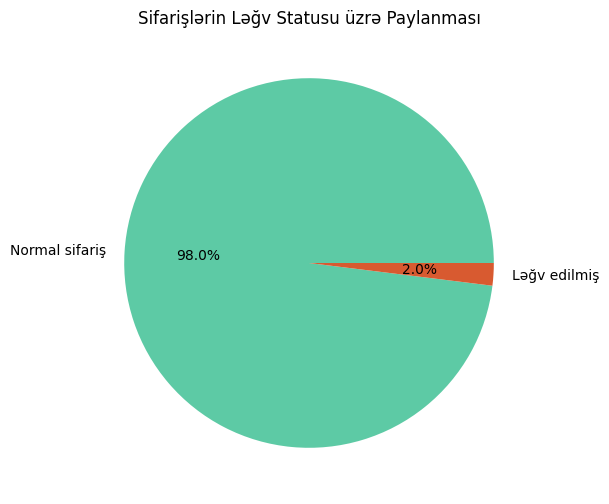

In [56]:
plt.figure(figsize=(6, 6))
df['Is_Cancelled'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Normal sifariş', 'Ləğv edilmiş'],
    colors=['#5DCAA5', '#D85A30']
)
plt.title('Sifarişlərin Ləğv Statusu üzrə Paylanması')
plt.ylabel('')
plt.show()

### Ən Çox Sifariş Verən Ölkələr
Hansı ölkələrin ən çox sifariş verdiyini araşdırıram.
**Nəticə:** United Kingdom sifarişlərin böyük əksəriyyətini təşkil edir
(~478,000), digər ölkələr (EIRE, Germany, France) xeyli aşağıdır — bu,
şirkətin əsasən UK-yönümlü fəaliyyət göstərdiyini təsdiqləyir.

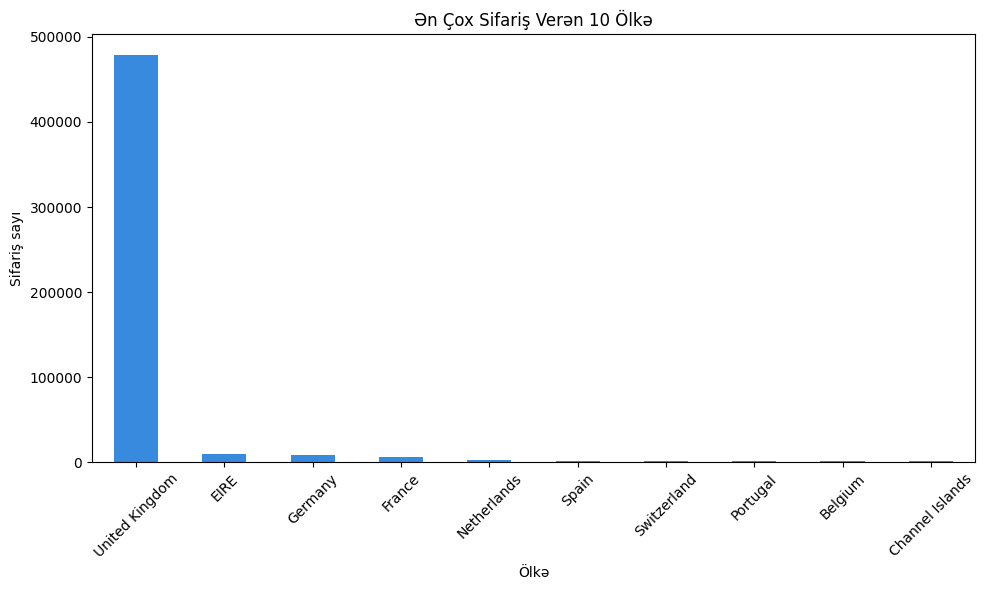

In [58]:
plt.figure(figsize=(10, 6))
df['Country'].value_counts().head(10).plot(kind='bar', color='#378ADD')
plt.title('Ən Çox Sifariş Verən 10 Ölkə')
plt.xlabel('Ölkə')
plt.ylabel('Sifariş sayı')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Quantity Paylanması
Sifariş miqdarının (Quantity) statistik paylanmasını araşdırıram.
**Nəticə:** Paylanmada bir neçə "pik" müşahidə olunur (0, ~12, ~25
ətrafında), bu, çox güman ki, standart paket ölçüləri (məs 12-lik, 24-lük)
ilə bağlıdır.

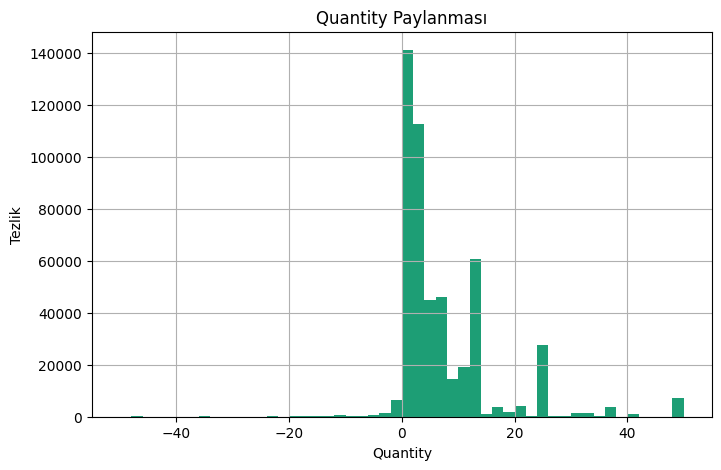

In [61]:
plt.figure(figsize=(8, 5))
df[df['Quantity'].between(-50, 50)]['Quantity'].hist(bins=50, color='#1D9E75')
plt.title('Quantity Paylanması')
plt.xlabel('Quantity')
plt.ylabel('Tezlik')
plt.show()



### Pareto Analizi — Müştəri Gəlir Konsentrasiyası
Az sayda müştərinin gəlirin çoxunu yaradıb-yaratmadığını yoxlayıram.Nəticə: Müştərilərin ilk 25-27%-i, ümumi gəlirin 80%-ni yaradır —
klassik "80/20 qaydası"na yaxın nəticədir. Əyri 100%-dən bir qədər yuxarı
çıxır (102%) — bu, bəzi müştərilərin xalis mənfi gəlirli (çoxlu geri
qaytarma edən) olması ilə izah olunur.

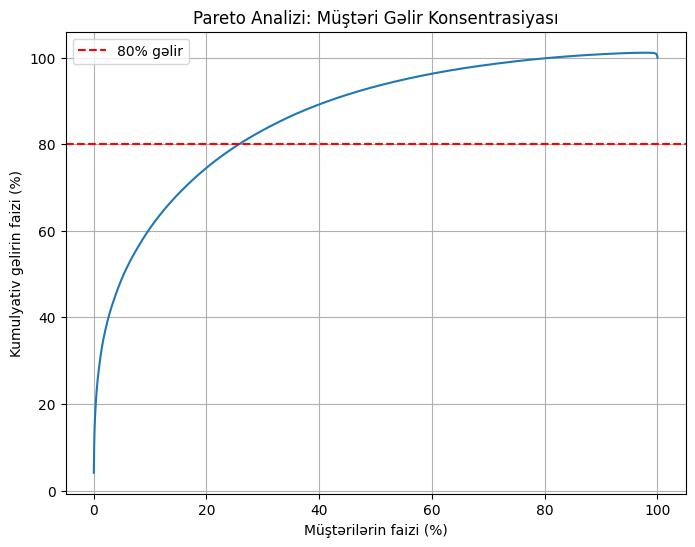

Müştərilərin ilk 20%-i, ümumi gəlirin 74.5%-ni yaradır


In [63]:
import numpy as np

customer_revenue = df[df['Customer ID'] != 'Unknown'].groupby('Customer ID')['TotalPrice'].sum().sort_values(ascending=False)

customer_revenue_cumsum = customer_revenue.cumsum() / customer_revenue.sum() * 100
customer_pct = (np.array(range(1, len(customer_revenue)+1)) / len(customer_revenue)) * 100

plt.figure(figsize=(8, 6))
plt.plot(customer_pct, customer_revenue_cumsum)
plt.axhline(80, color='red', linestyle='--', label='80% gəlir')
plt.xlabel('Müştərilərin faizi (%)')
plt.ylabel('Kumulyativ gəlirin faizi (%)')
plt.title('Pareto Analizi: Müştəri Gəlir Konsentrasiyası')
plt.legend()
plt.grid(True)
plt.show()

# Konkret rəqəm: gəlirin 80%-i neçə faiz müştəridən gəlir?
top_20_pct_count = int(len(customer_revenue) * 0.2)
top_20_revenue_share = customer_revenue.head(top_20_pct_count).sum() / customer_revenue.sum() * 100
print(f"Müştərilərin ilk 20%-i, ümumi gəlirin {top_20_revenue_share:.1f}%-ni yaradır")

### Saat və Gün üzrə Satış Pattern-i
İnsanların hansı vaxt daha çox alış-veriş etdiyini araşdırıram.
**Nəticə:** Satış aktivliyi güclü şəkildə iş saatlarında (9:00-16:00)
cəmləşib, gecə saatlarında demək olar ki heç bir satış yoxdur — B2B/
topdansatış modelinə işarə edir. Şənbə günü satış həcmi digər günlərdən
100 dəfədən çox aşağıdır.

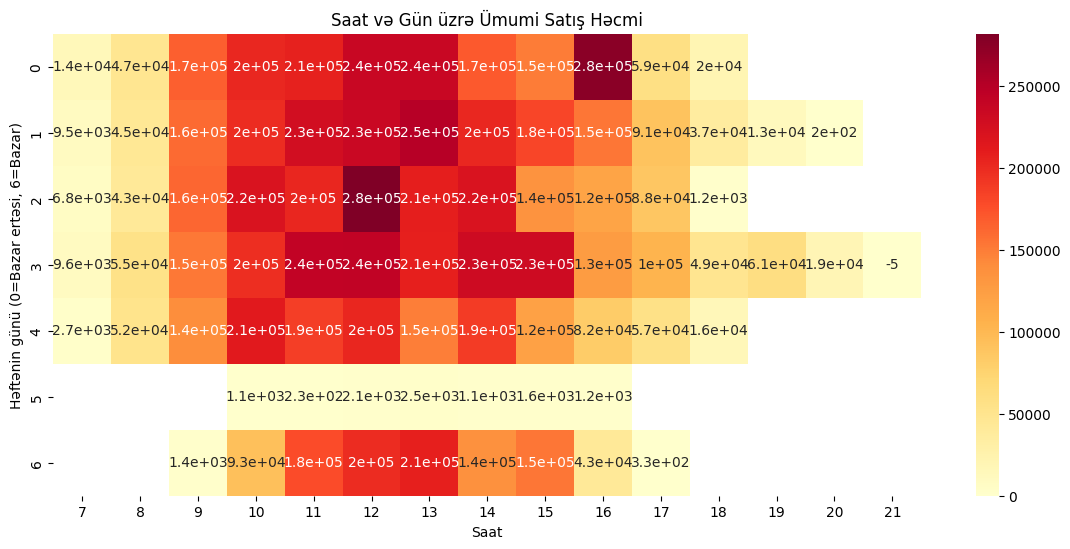

In [66]:
pivot = df.pivot_table(index='Purchase_DayofWeek', columns='Purchase_Hour', values='TotalPrice', aggfunc='sum')

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap='YlOrRd', annot=True)
plt.title('Saat və Gün üzrə Ümumi Satış Həcmi')
plt.xlabel('Saat')
plt.ylabel('Həftənin günü (0=Bazar ertəsi, 6=Bazar)')
plt.show()

### Ən Çox Satılan vs Ən Çox Gəlir Gətirən Məhsullar
İki siyahının üst-üstə düşüb-düşmədiyini müqayisə edirəm.
**Nəticə:** "Regency Cakestand 3 Tier" ən çox gəlir gətirən məhsuldur,
lakin top-10 ən çox satılanlar arasında yoxdur — yüksək qiymətli, aşağı
həcmli satış nümunəsidir. "DOTCOM POSTAGE" kimi qeyri-məhsul sətirlərin
gəlir siyahısında yer alması diqqətəlayiqdir — bunlar çatdırılma
xərcləridir, real məhsul satışı deyil.

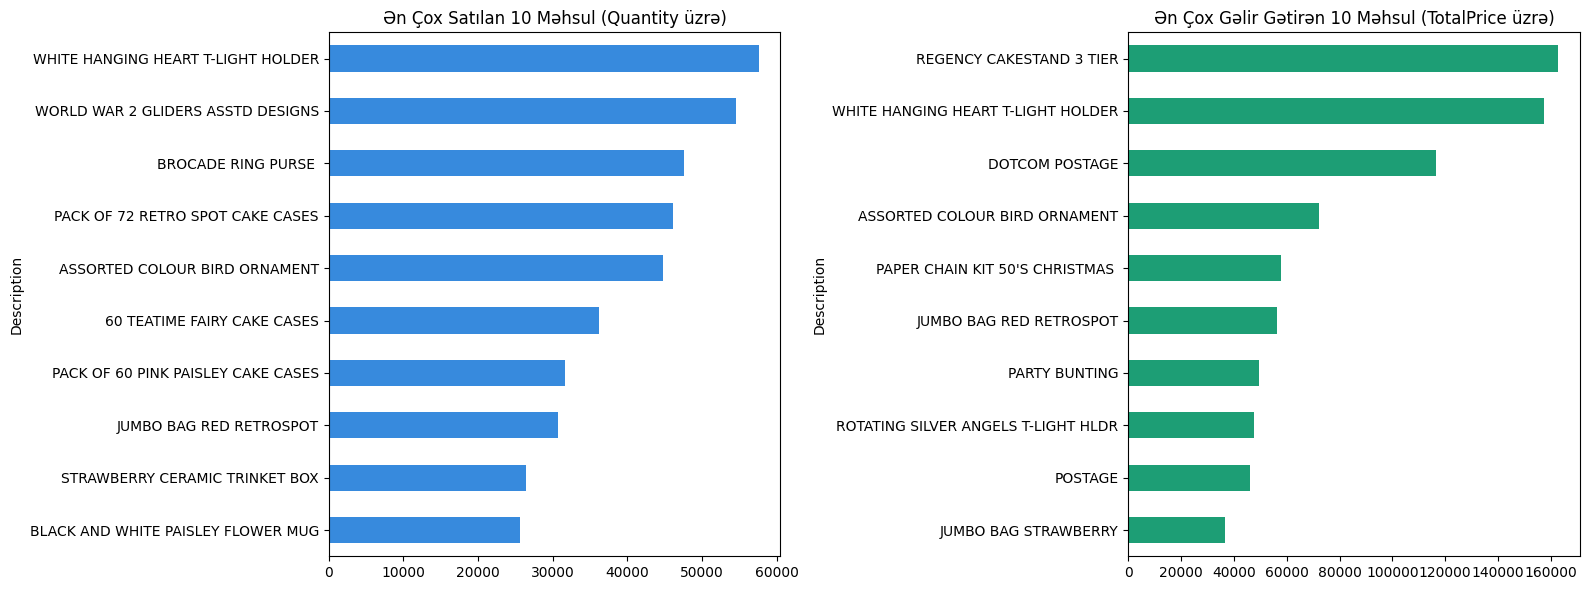

In [67]:
top_qty = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
top_revenue = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_qty.plot(kind='barh', ax=axes[0], color='#378ADD')
axes[0].set_title('Ən Çox Satılan 10 Məhsul (Quantity üzrə)')
axes[0].invert_yaxis()

top_revenue.plot(kind='barh', ax=axes[1], color='#1D9E75')
axes[1].set_title('Ən Çox Gəlir Gətirən 10 Məhsul (TotalPrice üzrə)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Ölkəyə görə Ləğv/Return Nisbəti
Hansı bazarların digərlərinə nisbətən daha çox geri qaytarma/ləğv
göstərdiyini araşdırıram (statistik etibarlılıq üçün yalnız kifayət qədər
sifarişi olan ölkələr daxil edilib).
Nəticə: Yaponiya ən yüksək return nisbətinə malikdir (27%) — bu, digər
ölkələrdən (əksəriyyəti 2-6% aralığında) kəskin şəkildə fərqlənir və
diqqətəlayiq bir "outlier bazar"dır. Channel Islands (9%) və UAE (7.5%)
də orta səviyyədən yuxarıdır. Əksinə, EIRE, Denmark və Cyprus ən aşağı
(2%) return nisbətinə malikdir. Bu fərq, gələcəkdə Yaponiya bazarında
məhsul uyğunluğu və ya çatdırılma prosesinin ayrıca araşdırılmasına
ehtiyac olduğunu göstərir.

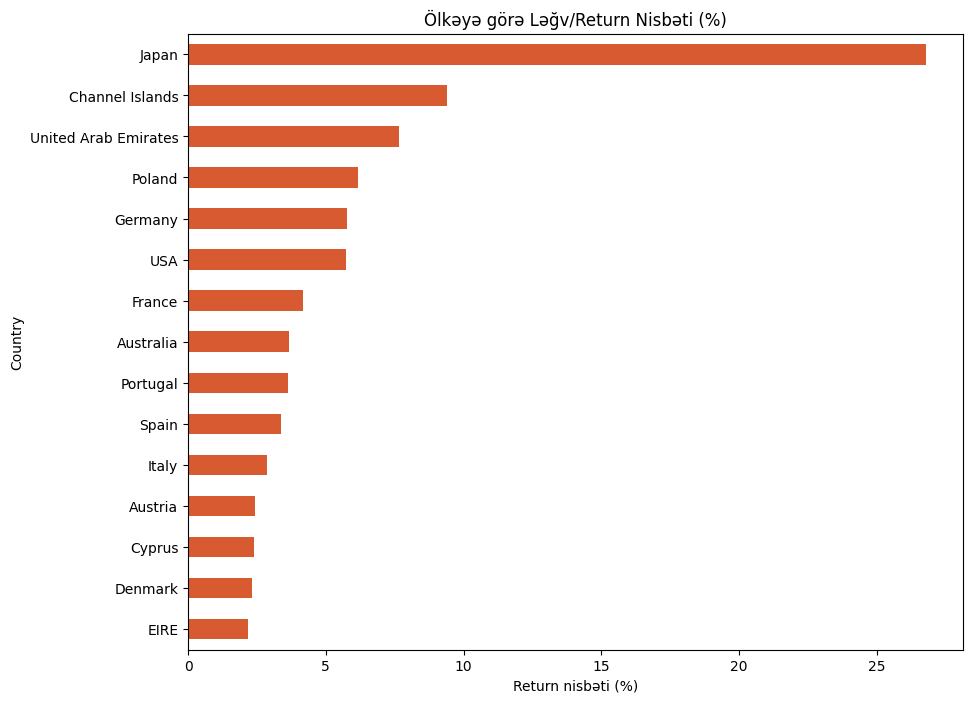

In [68]:
return_rate = df.groupby('Country')['Is_Cancelled'].mean().sort_values(ascending=False) * 100
return_rate_filtered = return_rate[df['Country'].value_counts() > 100]  # kiçik ölkələri çıxar (statistik etibarlılıq üçün)

plt.figure(figsize=(10, 8))
return_rate_filtered.head(15).plot(kind='barh', color='#D85A30')
plt.title('Ölkəyə görə Ləğv/Return Nisbəti (%)')
plt.xlabel('Return nisbəti (%)')
plt.gca().invert_yaxis()
plt.show()